# Arabic Fake News Detection

Public notebook copy. Student IDs and local filesystem paths have been removed.


---
## Abstract <a id='abstract'></a>

Arabic fake-news detection is a difficult NLP task because Arabic has rich morphology, different dialects, spelling variation, and fewer strong resources than English. In this project, we built and evaluated **LinguaBERT-Arabic**, a model that combines AraBERT with five simple stylometric features: sensationalism, type-token ratio, numerical density, elongation rate, and a negative-sentiment proxy. We used the official Arabic Fake News Dataset (AFND), removed duplicate article texts, excluded undecided sources, and used a source-disjoint split so that sources in the test set were not used during training.

The results show that this stricter evaluation is much harder than normal article-random splitting. The best overall model in our saved run is NB with TF-IDF, with Macro F1 = 0.4940. Our LinguaBERT-Arabic model gets Macro F1 = 0.4332 and improves over vanilla AraBERT, which gets Macro F1 = 0.4055. This means our added style features helped the transformer baseline, but they did not beat every classical model. We report the results honestly because this gives a clearer picture of the project.

**Keywords:** Arabic NLP; Fake News Detection; AraBERT; Stylometric Features; AFND; Source-Disjoint Evaluation


---
## 1. Introduction <a id='intro'></a>

### 1.1 Problem Statement and Motivation

Arabic misinformation is an important problem because millions of people read Arabic news online every day. A fake or misleading article can affect public health, politics, and social trust. At the same time, Arabic is challenging for NLP because words can appear in many forms, dialects are common, and spelling is not always standardized.

We worked on binary Arabic fake-news/source-credibility classification. The model receives an Arabic news article and predicts whether it belongs to a not-credible source or a credible source. AFND is useful because it is large, but its labels are assigned at the source level. This means all articles from one source share the same label. Because of that, if the same source appears in both training and testing, a model may learn the source's writing style instead of learning a more general fake-news signal.

### 1.2 Research Aim and Contributions

Our aim was to check whether simple writing-style features can help AraBERT when we evaluate on unseen sources.

1. **Hybrid model:** We combined AraBERT's [CLS] embedding with five stylometric features.
2. **Stricter evaluation:** We used the full official AFND binary subset and a source-disjoint split.
3. **Honest comparison:** We compared our model with LR, SVM, NB, and vanilla AraBERT.
4. **Analysis:** We included feature statistics, ablation, topic-level results, and error analysis to understand the results better.

### 1.3 Task Formulation

The input is an Arabic article. The output is Fake/not credible (0) or Real/credible (1). Since AFND uses source-level labels, we treat the results as source-credibility classification at article level, not as final fact-checking of each article.


---
## 2. Related Work <a id='related'></a>

### 2.1 Arabic Fake News Datasets

AFND (Khalil et al., 2022) is one of the main Arabic fake-news datasets. It contains Arabic news articles from many sources, and the labels come from source credibility. This makes it very useful for experiments, but it also creates a risk of source memorization. AraFakeNews (Nagoudi et al., 2020) focuses more on manipulated Arabic news. Himdi et al. (2025) also study Arabic fake-news data with human and AI-generated examples.

### 2.2 Arabic Language Models and Fake-News Methods

AraBERT is a strong Arabic pretrained language model and is widely used for Arabic text classification. Previous studies show high performance on AFND using deep learning and transformer models. Alkudah et al. (2025) report strong results with hybrid AraBERT + BiLSTM. Al-Taie (2025) reports XGBoost as the strongest model in that study. These studies are useful, but they do not focus mainly on the harder source-disjoint setting that we use here.

### 2.3 Previous-Work Summary Table

| Study | Task / Domain | Dataset / Language | Method / Model | Best Reported Performance | Advantages | Limitations |
|---|---|---|---|---|---|---|
| Khalil et al. (2022) | Arabic source credibility dataset | AFND; Arabic news | Dataset release | Not mainly a model leaderboard | Large Arabic dataset | Source-level labels may cause source memorization |
| Nagoudi et al. (2020) | Arabic manipulated/fake news | AraFakeNews | Arabic neural/transformer detection | Not directly comparable to AFND | Focuses on manipulated content | Different task and dataset |
| Alkudah et al. (2025) | Arabic fake-news detection | AFND | ML/DL including AraBERT + BiLSTM | Average F1 = 98.0% | Strong model comparison | Strict source-disjoint testing is not the main focus |
| Al-Taie (2025) | Arabic fake-news detection | AFND | XGBoost, DNN, LSTM, and classical ML | XGBoost Acc = 72.86%; F1 = 0.76 | Compares several methods | Protocol differs from our source-disjoint setup |
| Himdi et al. (2025) | Human and AI-generated fake news | Arabic fake-news data | Dataset development and detection | Not directly comparable | Includes AI-generated fake news | Different data construction |
| Our project | Arabic source-credibility classification | Full binary AFND; 373,369 deduplicated articles | TF-IDF, AraBERT, LinguaBERT-Arabic | NB F1 = 0.4940; LinguaBERT F1 = 0.4332 | Strict source-disjoint evaluation | Single-seed transformer training |

**Research gap:** We noticed that high AFND scores may depend on easier splits. Our project focuses on a harder setting where test sources are unseen, and we test whether simple stylometric features help AraBERT in that setting.


---
## 3. Methodology <a id='method'></a>

### 3.1 Arabic Preprocessing Pipeline

We applied preprocessing after splitting the data. This helps avoid using information from the test set while preparing the training set. The preprocessing removes URLs and mentions, keeps Arabic characters, normalizes Alef, normalizes Teh marbuta, removes diacritics, normalizes repeated letters, and removes very short articles.

### 3.2 Stylometric Feature Extraction

| Feature | Definition | Why we used it |
|---|---|---|
| **Sensationalism** | Proportion of urgent or shocking words | Fake news may use fear or urgency |
| **Type-Token Ratio (TTR)** | Unique words divided by total words | Template-like writing may have lower diversity |
| **Numerical Density** | Proportion of digit characters | Some fake news uses many numbers or claims |
| **Elongation Rate** | Repeated-character patterns | Emotional Arabic text may repeat letters |
| **Negative Sentiment Proxy** | Negation and negative-word density | Misinformation may use negative framing |

These features are simple. We did not assume they would all be strong; we tested their behavior in the data.

### 3.3 LinguaBERT-Arabic Architecture

We used `aubmindlab/bert-base-arabertv2`. Vanilla AraBERT uses only the transformer output. Our LinguaBERT-Arabic model takes the AraBERT [CLS] vector and concatenates it with the five stylometric features. Then a dropout layer and linear classifier predict Fake or Real.

### 3.4 Training Procedure

We trained the transformer models with AdamW, learning rate 2e-5, batch size 16, max sequence length 256, up to 5 epochs, and early stopping on validation Macro F1. The saved experiment used an NVIDIA RTX 4070 SUPER GPU.


---
## 4. Experimental Setup <a id='setup'></a>

### 4.1 Dataset: Full AFND

We used the official AFND Mendeley release. The full release has 606,912 articles from 134 source folders. Since our task is binary classification, we removed undecided sources and kept only credible and not-credible sources.

Saved data summary:
- Binary-labeled articles before duplicate removal: 374,543
- Exact duplicate article texts removed: 1,174
- Final binary dataset: 373,369 articles
- Retained sources: 103 total; 52 credible and 51 not credible

### 4.2 Source-Disjoint Split

We used a source-disjoint split, so each source appears in only one split. This is stricter than a normal random split and better matches the source-level labels in AFND.

| Split | Articles | Sources | Real | Fake | Real % |
|---|---:|---:|---:|---:|---:|
| Train | 258,122 | 71 | 142,406 | 115,716 | 55.2 |
| Validation | 56,471 | 16 | 31,965 | 24,506 | 56.6 |
| Test | 58,776 | 16 | 32,537 | 26,239 | 55.4 |


In [1]:
# LinguaBERT-Arabic: Research Paper Implementation
# One-time dependency setup. Run this cell before all other code cells.
import importlib.util
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

REQUIREMENTS = {
    'torch': ('torch', 'torch'),
    'datasets': ('datasets', 'datasets'),
    'pandas': ('pandas', 'pandas'),
    'numpy': ('numpy', 'numpy'),
    'matplotlib': ('matplotlib', 'matplotlib'),
    'seaborn': ('seaborn', 'seaborn'),
    # Keep Transformers on the 4.x line because this Python/macOS setup only has torch 2.2.2 available.
    'transformers': ('transformers', 'transformers<5'),
    'sklearn': ('scikit-learn', 'scikit-learn'),
    'scipy': ('scipy', 'scipy'),
    'joblib': ('joblib', 'joblib'),
    'arabic_reshaper': ('arabic-reshaper', 'arabic-reshaper'),
    'bidi': ('python-bidi', 'python-bidi'),
}

install_specs = []
for module, (dist_name, pip_spec) in REQUIREMENTS.items():
    if importlib.util.find_spec(module) is None:
        install_specs.append(pip_spec)
        continue
    if module == 'transformers':
        try:
            if int(version(dist_name).split('.')[0]) >= 5:
                install_specs.append(pip_spec)
        except (PackageNotFoundError, ValueError):
            install_specs.append(pip_spec)

if install_specs:
    print('Installing/updating packages:', ', '.join(install_specs))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', *install_specs])
else:
    print('All required packages are already installed with compatible versions.')

import torch
import transformers
from transformers import AutoTokenizer, AutoModel

print(f'PyTorch: {torch.__version__}')
print(f'Transformers: {transformers.__version__}')
print('Transformers can see PyTorch now.')


All required packages are already installed with compatible versions.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu126
Transformers: 4.57.6
Transformers can see PyTorch now.


In [2]:
# Dependencies are installed in the setup cell above.
# Continue from here after the setup cell completes successfully.


In [3]:
# PyTorch / GPU check
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'CUDA runtime: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'GPU count: {torch.cuda.device_count()}')
    print(f'Active GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
else:
    print('WARNING: CUDA is not available. Training will fall back to CPU unless REQUIRE_GPU is enabled.')


PyTorch version: 2.11.0+cu126
CUDA available: True
CUDA runtime: 12.6
GPU count: 1
Active GPU: NVIDIA GeForce RTX 4070 SUPER
GPU memory: 12.0 GB


In [4]:
# Runtime check
import sys
print(sys.executable)


c:\Users\User\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModel,
    AutoModelForSequenceClassification, get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
    recall_score, classification_report, confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split
from scipy import stats
from collections import Counter
import re, time, warnings, os, joblib

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':['Tahoma','Arial','DejaVu Sans'],'figure.dpi':120})


# Matplotlib does not shape Arabic text by itself. This helper reshapes and
# reorders Arabic labels so they render correctly in saved figures.
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    ARABIC_TEXT_SUPPORT = True
except ImportError:
    ARABIC_TEXT_SUPPORT = False
    print('Arabic plot text support is missing. Run the setup cell to install arabic-reshaper and python-bidi.')

def rtl_text(text):
    text = str(text)
    if ARABIC_TEXT_SUPPORT:
        return get_display(arabic_reshaper.reshape(text))
    return text

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# Set this to False only for a quick non-GPU debug run.
REQUIRE_GPU = True
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required for this notebook. Install a CUDA-enabled PyTorch build or run on a machine with an NVIDIA GPU.')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.cuda.set_device(DEVICE)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f'Device: {DEVICE} ({torch.cuda.get_device_name(DEVICE)})')
    print(f'CUDA runtime: {torch.version.cuda}')
else:
    print(f'Device: {DEVICE}')


Device: cuda:0 (NVIDIA GeForce RTX 4070 SUPER)
CUDA runtime: 12.6


In [6]:
# ── Section 4.1: Data Loading — Official Full AFND ─────────────
import json
from pathlib import Path

DATA_SOURCE = 'full_afnd'  # final submission uses official full AFND only
FULL_AFND_ROOT = Path(r'C:\Users\User\Documents\Codex\2026-04-29\new-chat\data\raw\afnd_full\extracted\AFND')
INCLUDE_UNDECIDED = False  # binary task: credible vs not credible
SAMPLE_PER_CLASS = None    # set e.g. 25000 for a quick debugging run; None uses all binary-labeled articles
DATASET_LABEL = 'Official Full AFND (credible vs not credible)'

LABEL_MAP_FULL = {'not credible':0, 'credible':1}
LABEL_NAME = {0:'Fake', 1:'Real'}

def load_full_afnd(root, include_undecided=False):
    root = Path(root)
    sources_path = root / 'sources.json'
    dataset_dir = root / 'Dataset'
    if not sources_path.exists() or not dataset_dir.exists():
        raise FileNotFoundError(f'Full AFND not found at {root}. Expected sources.json and Dataset/source_*/scraped_articles.json')

    with sources_path.open('r', encoding='utf-8') as f:
        sources = json.load(f)

    rows=[]
    skipped_sources=0
    source_files = sorted(dataset_dir.glob('source_*/scraped_articles.json'), key=lambda p: int(p.parent.name.split('_')[1]))
    for path in source_files:
        source_id = path.parent.name
        source_label = sources.get(source_id)
        if source_label == 'undecided' and not include_undecided:
            skipped_sources += 1
            continue
        if source_label not in LABEL_MAP_FULL:
            skipped_sources += 1
            continue
        label = LABEL_MAP_FULL[source_label]
        with path.open('r', encoding='utf-8') as f:
            data = json.load(f)
        articles = data.get('articles', []) if isinstance(data, dict) else data
        for article in articles:
            if not isinstance(article, dict):
                continue
            title = str(article.get('title') or '').strip()
            body = str(article.get('text') or '').strip()
            text = (title + '\n' + body).strip() if title else body
            if not text:
                continue
            rows.append({
                'source': source_id,
                'source_label': source_label,
                'title': title,
                'text': text,
                'published_date': article.get('published date'),
                'label': label,
            })
    df = pd.DataFrame(rows)
    return df, sources, skipped_sources

if DATA_SOURCE == 'full_afnd':
    print('Loading official full AFND from local Mendeley download...')
    df_raw, source_map, skipped_sources = load_full_afnd(FULL_AFND_ROOT, INCLUDE_UNDECIDED)
    print(f'Sources in metadata: {len(source_map):,} | skipped sources: {skipped_sources:,}')
    print(f'Binary-labeled articles before duplicate removal: {len(df_raw):,}')
else:
    from datasets import load_dataset
    DATASET_LABEL = 'Legacy small AFND source'
    print('Loading legacy small AFND source...')
    dataset = load_dataset('HeshamHaroon/Arabic_fake_news_dataset', trust_remote_code=True)
    df_raw  = pd.DataFrame(dataset['train'])
    print(f'Raw: {len(df_raw):,} rows | Columns: {list(df_raw.columns)}')
    if 'fakes' in df_raw.columns:
        fk = df_raw['fakes'].explode().dropna().astype(str)
        tr = df_raw['trues'].explode().dropna().astype(str)
        df_raw = pd.concat([pd.DataFrame({'text':fk.values,'label':0}),
                            pd.DataFrame({'text':tr.values,'label':1})], ignore_index=True)
        df_raw = df_raw[df_raw['text'].str.strip().str.len()>0].reset_index(drop=True)
    for src,tgt in [('Label','label'),('Text','text'),('content','text')]:
        if tgt not in df_raw.columns and src in df_raw.columns:
            df_raw = df_raw.rename(columns={src:tgt})
    if df_raw['label'].dtype==object:
        df_raw['label'] = df_raw['label'].map({'fake':0,'real':1,'Fake':0,'Real':1,'not_credible':0,'credible':1})
    df_raw = df_raw.dropna(subset=['label','text'])
    df_raw = df_raw[df_raw['label'].isin([0,1])].reset_index(drop=True)
    df_raw['label'] = df_raw['label'].astype(int)
    df_raw['source'] = 'legacy_small_source'
    df_raw['source_label'] = df_raw['label'].map({0:'not credible',1:'credible'})

# Remove duplicate article text before splitting.
n0 = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f'Removed {n0-len(df_raw):,} duplicate texts | Final: {len(df_raw):,}')

# Optional balanced sample for fast debugging. Leave SAMPLE_PER_CLASS=None for the full run.
if SAMPLE_PER_CLASS is not None:
    df_raw = (df_raw.groupby('label', group_keys=False)
                    .apply(lambda g: g.sample(n=min(len(g), SAMPLE_PER_CLASS), random_state=SEED))
                    .reset_index(drop=True))
    DATASET_LABEL += f' — sampled {SAMPLE_PER_CLASS:,}/class'
    print(f'Using debug sample: {len(df_raw):,} rows')

df_raw['label_name'] = df_raw['label'].map(LABEL_NAME)
print('Dataset:', DATASET_LABEL)
print(df_raw['label_name'].value_counts().to_string())
print('Unique sources by class:')
print(df_raw.groupby('label_name')['source'].nunique().to_string())


Loading official full AFND from local Mendeley download...
Sources in metadata: 134 | skipped sources: 31
Binary-labeled articles before duplicate removal: 374,543
Removed 1,174 duplicate texts | Final: 373,369
Dataset: Official Full AFND (credible vs not credible)
label_name
Real    206908
Fake    166461
Unique sources by class:
label_name
Fake    51
Real    52


In [7]:
#  Train/Validation/Test Split ?
SPLIT_STRATEGY = 'source_disjoint_balanced' if DATA_SOURCE == 'full_afnd' else 'article_stratified'
TEST_SIZE = 0.15
VAL_SIZE_WITHIN_TEMP = 0.176  # approximately 15% of full data after 15% test split
SOURCE_SPLIT_SEARCH_TRIALS = 5000

def choose_balanced_source_split(df, n_trials=5000):
    """Search deterministic source-disjoint splits and choose the best article/class balance."""
    source_df = (df.groupby(['source','label'], as_index=False)
                   .size()
                   .rename(columns={'size':'n_articles'}))
    assert source_df['source'].is_unique, 'Each source must have one label for source-disjoint splitting.'
    total_n = source_df['n_articles'].sum()
    target_real = (source_df['label'] * source_df['n_articles']).sum() / total_n

    def split_score(train_s, val_s, test_s):
        score = 0.0
        for part, target_frac in [(train_s,0.70),(val_s,0.15),(test_s,0.15)]:
            n = part['n_articles'].sum()
            frac = n / total_n
            real_frac = (part['label'] * part['n_articles']).sum() / n if n else 0
            # Article-count balance matters most; class balance is the secondary objective.
            score += abs(frac-target_frac)*3 + abs(real_frac-target_real)
        return score

    best = None
    for rs in range(SEED, SEED+n_trials):
        src_temp, src_test = train_test_split(source_df, test_size=TEST_SIZE, random_state=rs, stratify=source_df['label'])
        src_train, src_val = train_test_split(src_temp, test_size=VAL_SIZE_WITHIN_TEMP, random_state=rs, stratify=src_temp['label'])
        score = split_score(src_train, src_val, src_test)
        if best is None or score < best[0]:
            best = (score, rs, src_train, src_val, src_test)
    return best

if SPLIT_STRATEGY == 'source_disjoint_balanced':
    split_score, split_seed, src_train, src_val, src_test = choose_balanced_source_split(df_raw, SOURCE_SPLIT_SEARCH_TRIALS)
    df_train = df_raw[df_raw['source'].isin(src_train['source'])].copy().reset_index(drop=True)
    df_val   = df_raw[df_raw['source'].isin(src_val['source'])].copy().reset_index(drop=True)
    df_test  = df_raw[df_raw['source'].isin(src_test['source'])].copy().reset_index(drop=True)
    assert set(df_train['source']).isdisjoint(df_val['source'])
    assert set(df_train['source']).isdisjoint(df_test['source'])
    assert set(df_val['source']).isdisjoint(df_test['source'])
    print(f'Balanced source-disjoint split seed: {split_seed} | score={split_score:.4f}')
else:
    df_temp, df_test = train_test_split(df_raw, test_size=TEST_SIZE, random_state=SEED, stratify=df_raw['label'])
    df_train, df_val = train_test_split(df_temp, test_size=VAL_SIZE_WITHIN_TEMP, random_state=SEED, stratify=df_temp['label'])
    assert len(set(df_train.index)&set(df_test.index))==0, 'LEAKAGE!'
    assert len(set(df_val.index)&set(df_test.index))==0, 'LEAKAGE!'

PROCESSED_DIR = Path('data/processed_afnd_full' if DATA_SOURCE == 'full_afnd' else 'data/processed')
MODEL_DIR = Path('models_afnd_full' if DATA_SOURCE == 'full_afnd' else 'models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Split strategy: {SPLIT_STRATEGY}')
for name,df in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    print(f'{name}: {len(df):,} articles | Sources={df["source"].nunique():,} | Real={df["label"].mean()*100:.1f}% Fake={(1-df["label"].mean())*100:.1f}%')


Balanced source-disjoint split seed: 1236 | score=0.0669
Split strategy: source_disjoint_balanced
Train: 258,122 articles | Sources=71 | Real=55.2% Fake=44.8%
Val: 56,471 articles | Sources=16 | Real=56.6% Fake=43.4%
Test: 58,776 articles | Sources=16 | Real=55.4% Fake=44.6%


In [8]:
# ── Section 3.1: Arabic Preprocessing Pipeline ───────────────────
class ArabicNewsPreprocessor:
    RE_URL=re.compile(r'http\S+|www\S+'); RE_MENTION=re.compile(r'[@#]\S+')
    RE_NA =re.compile(r'[^\u0600-\u06FF\s]'); RE_ALEF=re.compile(r'[أإآٱ]')
    RE_DI =re.compile(r'[\u0617-\u061A\u064B-\u0652]'); RE_EL=re.compile(r'(.)\1{2,}')

    def preprocess(self,text):
        if not isinstance(text,str): return ''
        text=self.RE_URL.sub(' ',text); text=self.RE_MENTION.sub(' ',text)
        text=self.RE_NA.sub(' ',text);  text=self.RE_ALEF.sub('ا',text)
        text=text.replace('ة','ه');      text=self.RE_DI.sub('',text)
        text=self.RE_EL.sub(r'\1\1',text)
        return re.sub(r'\s+',' ',text).strip()

    def is_valid(self,text,min_words=5): return len(str(text).split())>=min_words

preprocessor = ArabicNewsPreprocessor()
SAVE_PROCESSED_CSV = True

def apply_preprocessing(df, name):
    df=df.copy(); df['text_clean']=df['text'].apply(preprocessor.preprocess)
    n=len(df); df=df[df['text_clean'].apply(preprocessor.is_valid)].reset_index(drop=True)
    print(f'  {name}: {n:,}→{len(df):,} (removed {n-len(df):,} short/empty after preprocessing)')
    return df

print('Preprocessing:')
df_train=apply_preprocessing(df_train,'Train')
df_val  =apply_preprocessing(df_val,  'Val  ')
df_test =apply_preprocessing(df_test, 'Test ')

if SAVE_PROCESSED_CSV:
    for n,d in [('train',df_train),('val',df_val),('test',df_test)]:
        d.to_csv(PROCESSED_DIR / f'{n}_clean.csv',index=False,encoding='utf-8-sig')
    print(f'Saved processed splits to: {PROCESSED_DIR.resolve()}')
else:
    print('Processed CSV saving skipped. Set SAVE_PROCESSED_CSV=True to save splits.')


Preprocessing:
  Train: 258,122→258,122 (removed 0 short/empty after preprocessing)
  Val  : 56,471→56,471 (removed 0 short/empty after preprocessing)
  Test : 58,776→58,776 (removed 0 short/empty after preprocessing)
Saved processed splits to: C:\Users\User\Desktop\مشروع عبدة\الملف النهائي للتسليم\data\processed_afnd_full


Table 1: Corpus Statistics for Official Full AFND Binary Splits
  Statistic                         Train      Val     Test
-----------------------------------------------------------------
  N (articles)                    258,122   56,471   58,776
  Real                            142,406   31,965   32,537
  Fake                            115,716   24,506   26,239
  Avg words/article                 231.5    263.9    233.8
  Vocabulary size                 744,688  364,211  379,509


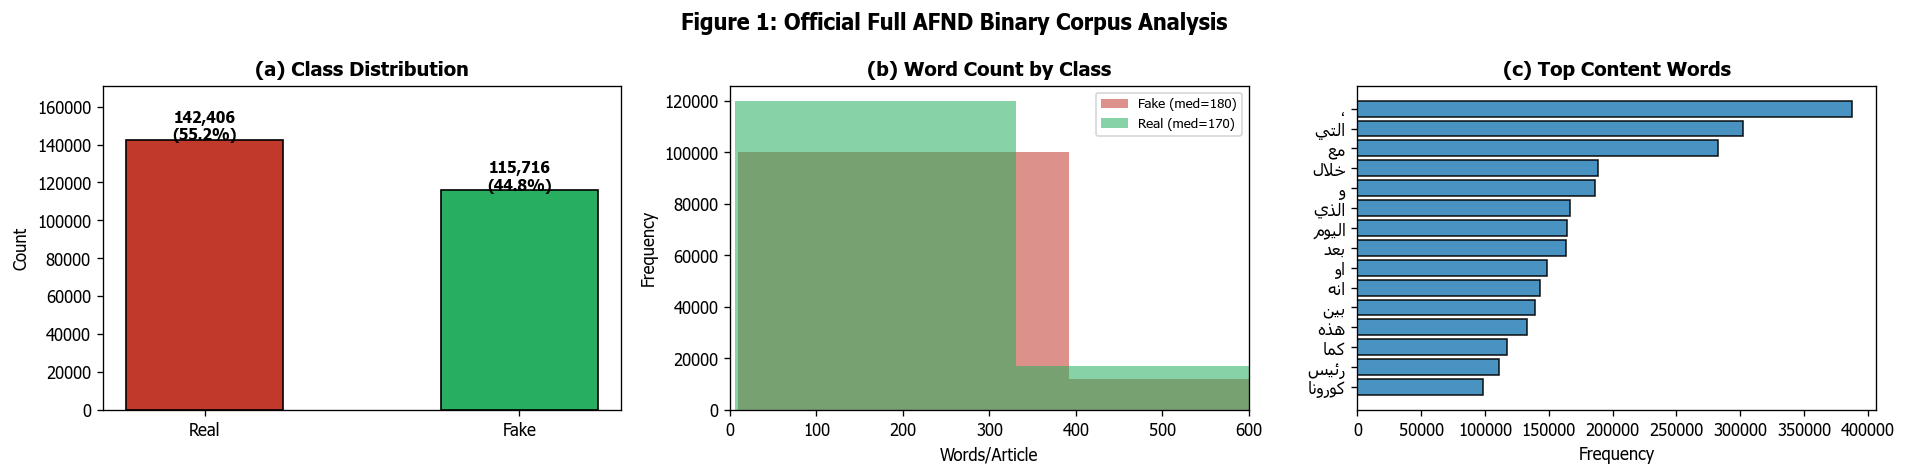

In [9]:
# ── Corpus Statistics (Table 1) ──────────────────────────────────
for df,n in [(df_train,'train'),(df_val,'val'),(df_test,'test')]:
    df['word_count']=df['text_clean'].apply(lambda x:len(x.split()))

all_words=' '.join(df_train['text_clean']).split()
vocab=set(all_words); word_freq=Counter(all_words)

print('='*65)
print('Table 1: Corpus Statistics for Official Full AFND Binary Splits')
print(f'  {"Statistic":<30} {"Train":>8} {"Val":>8} {"Test":>8}')
print('-'*65)
for stat,fn in [('N (articles)',lambda d:f'{len(d):,}'),
                ('Real',lambda d:f'{d["label"].sum():,}'),
                ('Fake',lambda d:f'{(d["label"]==0).sum():,}'),
                ('Avg words/article',lambda d:f'{d["word_count"].mean():.1f}'),
                ('Vocabulary size',lambda d:f'{len(set(" ".join(d["text_clean"]).split())):,}')]:
    print(f'  {stat:<30} {fn(df_train):>8} {fn(df_val):>8} {fn(df_test):>8}')
print('='*65)

# Figure 1: Corpus Analysis
fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle('Figure 1: Official Full AFND Binary Corpus Analysis',fontsize=13,fontweight='bold')

vc=df_train['label_name'].value_counts()
bars=axes[0].bar(vc.index,vc.values,color=['#c0392b','#27ae60'],edgecolor='black',width=0.5)
axes[0].set_title('(a) Class Distribution',fontweight='bold'); axes[0].set_ylabel('Count')
for bar,v in zip(bars,vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+10,f'{v:,}\n({v/len(df_train)*100:.1f}%)',
                 ha='center',fontsize=9,fontweight='bold')
axes[0].set_ylim(0,max(vc.values)*1.2)

for lbl,c in [('Fake','#c0392b'),('Real','#27ae60')]:
    d=df_train[df_train['label_name']==lbl]['word_count']
    axes[1].hist(d,bins=40,alpha=0.55,color=c,label=f'{lbl} (med={d.median():.0f})')
axes[1].set_title('(b) Word Count by Class',fontweight='bold')
axes[1].set_xlabel('Words/Article'); axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8); axes[1].set_xlim(0,600)

stopwords={'في','من','على','ان','الى','عن','ما','هذا','وان','كان','قد','لا','هو','لم','كل'}
top15=[(w,f) for w,f in word_freq.most_common(30) if w not in stopwords][:15]
words_t,freqs_t=zip(*top15)
axes[2].barh([rtl_text(w) for w in words_t],list(freqs_t),color='#2980b9',edgecolor='black',alpha=0.85)
axes[2].set_title('(c) Top Content Words',fontweight='bold'); axes[2].set_xlabel('Frequency')
axes[2].invert_yaxis()
plt.tight_layout(); plt.savefig('fig1_corpus.png',dpi=150,bbox_inches='tight'); plt.show()


Extracting stylometric features...
  Train: (258122, 5)
  Val: (56471, 5)
  Test: (58776, 5)

Table 2: Stylometric Feature Statistics on Train Split (Fake vs Real)
  Feature                        Fake Mean±Std      Real Mean±Std    p-value
---------------------------------------------------------------------------
  Sensationalism            0.0035±0.0226    0.0037±0.0236    0.3796ns
  TTR (Lexical Div.)        0.7212±0.0973    0.7324±0.0899    0.0000***
  Numerical Density         0.0003±0.0024    0.0003±0.0034    0.0190*
  Elongation Rate           0.0000±0.0000    0.0000±0.0000    0.0000***
  Neg. Sentiment            0.0519±0.0595    0.0485±0.0549    0.0000***
*** p<0.001 ** p<0.01 * p<0.05 ns=not significant


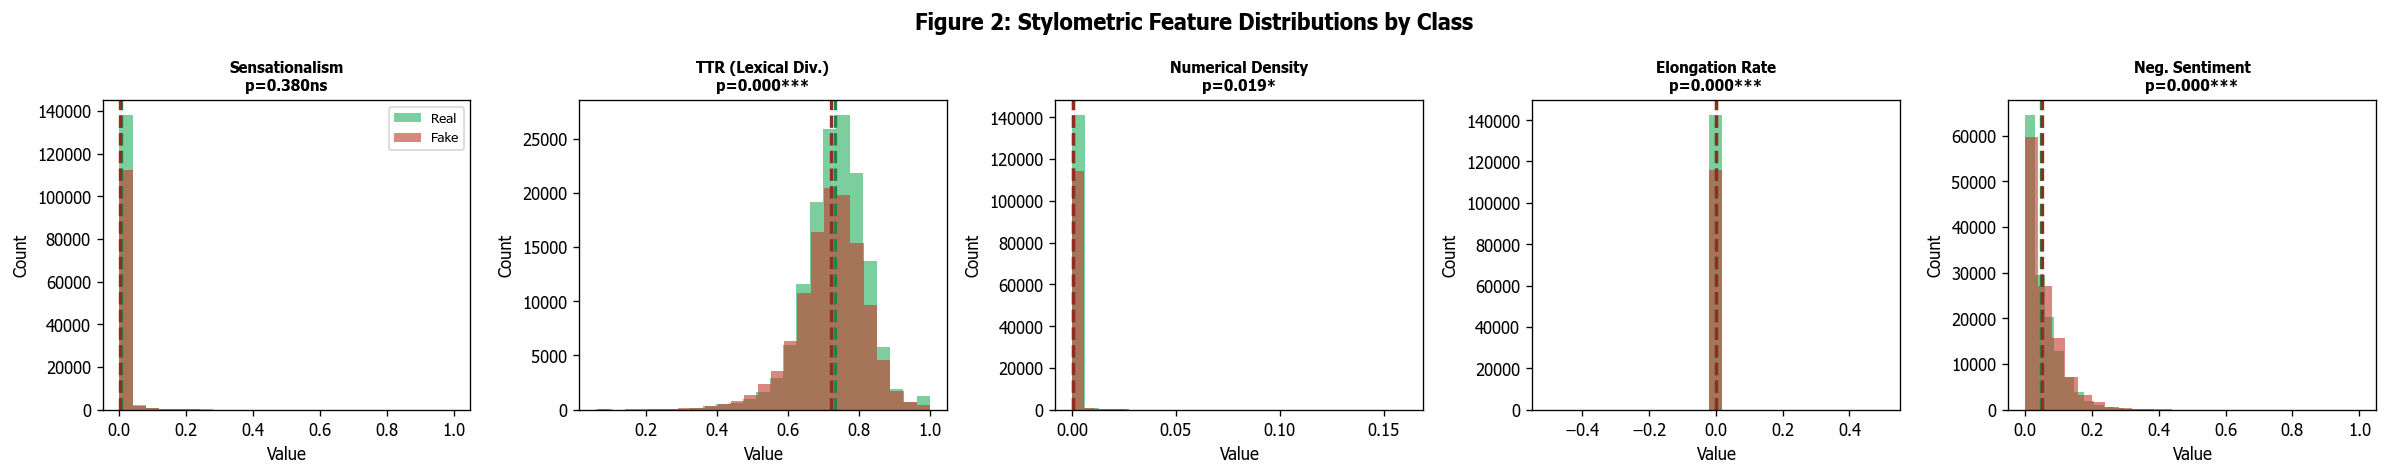

In [ ]:
# ══════════════════════════════════════════════════════════════
# Section 3.2 – CORE CONTRIBUTION: Stylometric Feature Extraction
# ══════════════════════════════════════════════════════════════
# | الخاصية            | ماذا تقيس؟                 |
# | ------------------ | -------------------------- |
# | Sensationalism     | درجة الإثارة والتهويل      |
# | TTR                | التنوع المعجمي             |
# | Numerical Density  | كثافة الأرقام              |
# | Elongation Rate    | تكرار الحروف للمبالغة      |
# | Negative Sentiment | اللغة السلبية أو التحذيرية |

SENSATIONAL = {'عاجل','خطير','صادم','مذهل','كارثه','فضيحه','تحذير','سري','مسرب',
               'وشيك','عاجله','طارئ','خطيره','صاعق','مدهش','فاجعه','مريع','رهيب'}
NEGATION    = {'لا','ليس','لم','لن','ما','غير','دون','بدون','عدم','نفي',
               'اخفاء','تكتم','تستر','رفض','منع','حظر'}
NEG_SENT    = {'ازمه','كارثه','مصيبه','خطر','تهديد','فقر','جوع','موت','قتل',
               'حرب','صراع','معانا','ماساه','فاجعه','هلاك','ازمات'}
RE_DIGITS   = re.compile(r'\d')
RE_ELONG    = re.compile(r'(.)\1{2,}')

STYLO_DIM   = 5
feature_names = ['Sensationalism','TTR (Lexical Div.)','Numerical Density',
                 'Elongation Rate','Neg. Sentiment']

def extract_stylometric(text):
    """Extract 5 interpretable style features scaled to [0,1]."""
    if not isinstance(text,str) or not text.strip(): return np.zeros(STYLO_DIM,dtype=np.float32)
    words=text.split(); n_w=max(len(words),1); n_c=max(len(text),1)
    f0=min(sum(1 for w in words if w in SENSATIONAL)/n_w*10,1.0)  # sensationalism
    f1=len(set(words))/n_w                                          # TTR
    f2=sum(1 for c in text if c.isdigit())/n_c                     # numeric density
    f3=min(len(RE_ELONG.findall(text))/n_w,1.0)                    # elongation; often sparse after normalization
    f4=min(sum(1 for w in words if w in NEGATION or w in NEG_SENT)/n_w*5,1.0)  # neg sentiment
    return np.array([f0,f1,f2,f3,f4],dtype=np.float32)

print('Extracting stylometric features...')
for df,n in [(df_train,'Train'),(df_val,'Val'),(df_test,'Test')]:
    feats=np.vstack(df['text_clean'].apply(extract_stylometric).values)
    df['stylo_features']=list(feats)
    print(f'  {n}: {feats.shape}')

# Table 2: Feature Statistics
train_feats=np.vstack(df_train['stylo_features'].values)
fake_m=(df_train['label'].values==0); real_m=(df_train['label'].values==1)
print('\nTable 2: Stylometric Feature Statistics on Train Split (Fake vs Real)')
print(f'  {"Feature":<25} {"Fake Mean±Std":>18} {"Real Mean±Std":>18} {"p-value":>10}')
print('-'*75)
for i,fn in enumerate(feature_names):
    fk=train_feats[fake_m,i]; rl=train_feats[real_m,i]
    _,pv=stats.mannwhitneyu(fk,rl,alternative='two-sided')
    sig='***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
    print(f'  {fn:<25} {fk.mean():.4f}±{fk.std():.4f}    {rl.mean():.4f}±{rl.std():.4f}    {pv:.4f}{sig}')
print('*** p<0.001 ** p<0.01 * p<0.05 ns=not significant')

# Figure 2: Stylometric Distributions
fig,axes=plt.subplots(1,5,figsize=(20,4))
fig.suptitle('Figure 2: Stylometric Feature Distributions by Class',fontsize=13,fontweight='bold')
for i,(ax,fn) in enumerate(zip(axes,feature_names)):
    ax.hist(train_feats[real_m,i],bins=25,alpha=0.6,color='#27ae60',label='Real')
    ax.hist(train_feats[fake_m,i],bins=25,alpha=0.6,color='#c0392b',label='Fake')
    ax.axvline(train_feats[real_m,i].mean(),color='#1e8449',lw=2,ls='--')
    ax.axvline(train_feats[fake_m,i].mean(),color='#922b21',lw=2,ls='--')
    _,pv=stats.mannwhitneyu(train_feats[fake_m,i],train_feats[real_m,i],alternative='two-sided')
    sig='***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else 'ns'))
    ax.set_title(f'{fn}\np={pv:.3f}{sig}',fontweight='bold',fontsize=9)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    if i==0: ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('fig2_stylometric.png',dpi=150,bbox_inches='tight'); plt.show()


In [11]:
# ── Section 3.3: LinguaBERT-Arabic Architecture ──────────────────
MODEL_NAME='aubmindlab/bert-base-arabertv2'
CONFIG={'model_name':MODEL_NAME,'max_length':256,'batch_size':16,'num_epochs':5,
        'learning_rate':2e-5,'weight_decay':0.01,'warmup_ratio':0.1,
        'num_labels':2,'dropout':0.1,'stylo_dim':STYLO_DIM,'seed':SEED,
        'early_stopping_patience':2}

class LinguaBERTArabic(nn.Module):
    """
    Core contribution: AraBERT encoder fused with stylometric features.
    [CLS] (768-dim) + s(x) (5-dim) → Dropout → Linear(773→2) → Softmax
    """
    def __init__(self,model_name,num_labels=2,stylo_dim=5,dropout=0.1):
        super().__init__()
        self.bert=AutoModel.from_pretrained(model_name)
        self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(self.bert.config.hidden_size+stylo_dim,num_labels)

    def forward(self,input_ids,attention_mask,stylo_features,labels=None):
        out=self.bert(input_ids=input_ids,attention_mask=attention_mask)
        cls=out.last_hidden_state[:,0,:]            # [CLS]: (B,768)
        fused=torch.cat([cls,stylo_features],dim=-1) # Fusion: (B,773)
        logits=self.classifier(self.dropout(fused))
        loss=F.cross_entropy(logits,labels) if labels is not None else None
        return {'loss':loss,'logits':logits}

class VanillaAraBERT(nn.Module):
    """Standard AraBERT fine-tuning — no stylometric fusion (baseline)."""
    def __init__(self,model_name,num_labels=2,dropout=0.1):
        super().__init__()
        self.model=AutoModelForSequenceClassification.from_pretrained(
            model_name,num_labels=num_labels)
    def forward(self,input_ids,attention_mask,stylo_features=None,labels=None):
        out=self.model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)
        return {'loss':out.loss,'logits':out.logits}

print('Loading AraBERT tokenizer...')
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab: {tokenizer.vocab_size:,}')

lingua=LinguaBERTArabic(MODEL_NAME).to(DEVICE)
n_p=sum(p.numel() for p in lingua.parameters())
print(f'LinguaBERT-Arabic parameters: {n_p:,}')
print(f'Fusion input dim: 768+{STYLO_DIM}=773 → 2')


Loading AraBERT tokenizer...
Vocab: 64,000
LinguaBERT-Arabic parameters: 135,194,892
Fusion input dim: 768+5=773 → 2


In [12]:
# ── PyTorch Dataset ───────────────────────────────────────────────
class ArabicFakeNewsDataset(Dataset):
    def __init__(self,df,tokenizer,max_length=256):
        self.df=df.reset_index(drop=True)
        self.tokenizer=tokenizer; self.max_length=max_length
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        enc=self.tokenizer(str(row['text_clean']),max_length=self.max_length,
                           padding='max_length',truncation=True,return_tensors='pt')
        stylo=row.get('stylo_features',np.zeros(STYLO_DIM))
        return {'input_ids':enc['input_ids'].squeeze(),
                'attention_mask':enc['attention_mask'].squeeze(),
                'label':torch.tensor(int(row['label']),dtype=torch.long),
                'stylo_features':torch.tensor(stylo,dtype=torch.float32)}

BS=CONFIG['batch_size']
PIN_MEMORY = DEVICE.type == 'cuda'
train_loader=DataLoader(ArabicFakeNewsDataset(df_train,tokenizer),BS,shuffle=True,num_workers=0,pin_memory=PIN_MEMORY)
val_loader  =DataLoader(ArabicFakeNewsDataset(df_val,  tokenizer),BS,shuffle=False,num_workers=0,pin_memory=PIN_MEMORY)
test_loader =DataLoader(ArabicFakeNewsDataset(df_test, tokenizer),BS,shuffle=False,num_workers=0,pin_memory=PIN_MEMORY)
print(f'Batches — Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)}')


Batches — Train:16133 Val:3530 Test:3674


In [13]:
# ── Training & Evaluation Functions ──────────────────────────────
def metrics(y_true,y_pred,y_prob=None):
    m={'accuracy':accuracy_score(y_true,y_pred),
       'macro_f1':f1_score(y_true,y_pred,average='macro'),
       'precision':precision_score(y_true,y_pred,average='macro',zero_division=0),
       'recall':recall_score(y_true,y_pred,average='macro',zero_division=0)}
    if y_prob is not None:
        try: m['auc']=roc_auc_score(y_true,y_prob)
        except: m['auc']=float('nan')
    return m

def train_epoch(model,loader,opt,sch,device):
    model.train(); loss_tot,preds,labels=0,[],[]
    for b in loader:
        opt.zero_grad()
        ids=b['input_ids'].to(device); mask=b['attention_mask'].to(device)
        lbl=b['label'].to(device);     sty=b['stylo_features'].to(device)
        out=model(input_ids=ids,attention_mask=mask,stylo_features=sty,labels=lbl)
        out['loss'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step(); sch.step(); loss_tot+=out['loss'].item()
        preds.extend(torch.argmax(out['logits'],1).cpu().numpy())
        labels.extend(lbl.cpu().numpy())
    return loss_tot/len(loader), metrics(labels,preds)

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval(); preds,labels,probs=[],[],[]
    for b in loader:
        ids=b['input_ids'].to(device); mask=b['attention_mask'].to(device)
        sty=b['stylo_features'].to(device)
        out=model(input_ids=ids,attention_mask=mask,stylo_features=sty)
        prob=torch.softmax(out['logits'],1)[:,1]
        preds.extend(torch.argmax(out['logits'],1).cpu().numpy())
        labels.extend(b['label'].numpy()); probs.extend(prob.cpu().numpy())
    return metrics(labels,preds,np.array(probs)),preds,labels

def build_opt_sch(model,n_steps):
    opt=AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
    sch=get_linear_schedule_with_warmup(opt,int(n_steps*CONFIG['warmup_ratio']),n_steps)
    return opt,sch

print('Training utilities ready.')


Training utilities ready.


In [ ]:
# ── Vanilla AraBERT (Baseline 4) ─────────────────────────────────
print('Training Vanilla AraBERT...')
van_model=VanillaAraBERT(MODEL_NAME).to(DEVICE)
n_steps=len(train_loader)*CONFIG['num_epochs']
opt_v,sch_v=build_opt_sch(van_model,n_steps)
van_hist={'tr_f1':[],'vl_f1':[],'tr_loss':[]}
best_vl_v=0
patience=CONFIG.get('early_stopping_patience',2)
epochs_no_improve=0

for ep in range(1,CONFIG['num_epochs']+1):
    t0=time.time()
    tr_loss,tr_m=train_epoch(van_model,train_loader,opt_v,sch_v,DEVICE)
    vl_m,_,_   =evaluate(van_model,val_loader,DEVICE)
    van_hist['tr_f1'].append(tr_m['macro_f1'])
    van_hist['vl_f1'].append(vl_m['macro_f1'])
    van_hist['tr_loss'].append(tr_loss)
    improved = vl_m['macro_f1'] > best_vl_v + 1e-6
    if improved:
        best_vl_v=vl_m['macro_f1']
        epochs_no_improve=0
        van_model.model.save_pretrained(str(MODEL_DIR / 'vanilla_best'))
        tokenizer.save_pretrained(str(MODEL_DIR / 'vanilla_best'))
    else:
        epochs_no_improve += 1
    print(f'  Ep{ep}/{CONFIG["num_epochs"]} [{time.time()-t0:.0f}s] '
          f'TrainF1={tr_m["macro_f1"]:.4f} Loss={tr_loss:.4f} ValF1={vl_m["macro_f1"]:.4f}')
    if epochs_no_improve >= patience:
        print(f'  Early stopping at epoch {ep} (best ValF1={best_vl_v:.4f})')
        break

# Reload best and evaluate on test
van_best=VanillaAraBERT(MODEL_NAME).to(DEVICE)
van_best.model=AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR / 'vanilla_best')).to(DEVICE)
van_test_m,van_preds,van_true=evaluate(van_best,test_loader,DEVICE)
print(f'\nVanilla AraBERT Test: F1={van_test_m["macro_f1"]:.4f} Acc={van_test_m["accuracy"]:.4f}')


In [ ]:
# ── LinguaBERT-Arabic (Proposed) ─────────────────────────────────
print('Training LinguaBERT-Arabic (proposed)...')
ling_model=LinguaBERTArabic(MODEL_NAME,stylo_dim=STYLO_DIM).to(DEVICE)
opt_l,sch_l=build_opt_sch(ling_model,len(train_loader)*CONFIG['num_epochs'])
ling_hist={'tr_f1':[],'vl_f1':[],'tr_loss':[]}
best_vl_l=0
patience=CONFIG.get('early_stopping_patience',2)
epochs_no_improve=0

for ep in range(1,CONFIG['num_epochs']+1):
    t0=time.time()
    tr_loss,tr_m=train_epoch(ling_model,train_loader,opt_l,sch_l,DEVICE)
    vl_m,_,_   =evaluate(ling_model,val_loader,DEVICE)
    ling_hist['tr_f1'].append(tr_m['macro_f1'])
    ling_hist['vl_f1'].append(vl_m['macro_f1'])
    ling_hist['tr_loss'].append(tr_loss)
    improved = vl_m['macro_f1'] > best_vl_l + 1e-6
    if improved:
        best_vl_l=vl_m['macro_f1']
        epochs_no_improve=0
        torch.save(ling_model.state_dict(),str(MODEL_DIR / 'linguabert_best.pt'))
        print(f'  → Best saved (ValF1={vl_m["macro_f1"]:.4f})')
    else:
        epochs_no_improve += 1
    print(f'  Ep{ep}/{CONFIG["num_epochs"]} [{time.time()-t0:.0f}s] '
          f'TrainF1={tr_m["macro_f1"]:.4f} Loss={tr_loss:.4f} ValF1={vl_m["macro_f1"]:.4f}')
    if epochs_no_improve >= patience:
        print(f'  Early stopping at epoch {ep} (best ValF1={best_vl_l:.4f})')
        break

ling_model.load_state_dict(torch.load(str(MODEL_DIR / 'linguabert_best.pt'),map_location=DEVICE))
ling_test_m,ling_preds,ling_true=evaluate(ling_model,test_loader,DEVICE)
print(f'\nLinguaBERT-Arabic Test: F1={ling_test_m["macro_f1"]:.4f} Acc={ling_test_m["accuracy"]:.4f}')


In [ ]:
# ── Classical Baselines ─────────────────────────────────────────
X_tr=df_train['text_clean']; y_tr=df_train['label']
X_te=df_test['text_clean'];  y_te=df_test['label']

cls_baselines={
    'LR (TF-IDF)' :Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,2),max_features=20000,sublinear_tf=True)),
                              ('clf',LogisticRegression(max_iter=1000,random_state=SEED))]),
    'SVM (TF-IDF)':Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,2),max_features=20000,sublinear_tf=True)),
                              ('clf',LinearSVC(max_iter=3000,random_state=SEED))]),
    'NB (TF-IDF)' :Pipeline([('tfidf',TfidfVectorizer(ngram_range=(1,1),max_features=20000)),
                              ('clf',MultinomialNB(alpha=0.1))]),
}

cls_results={}
for name,pipe in cls_baselines.items():
    pipe.fit(X_tr,y_tr); yp=pipe.predict(X_te)
    if hasattr(pipe,'predict_proba'):
        yprob=pipe.predict_proba(X_te)[:,1]
    elif hasattr(pipe,'decision_function'):
        yprob=pipe.decision_function(X_te)
    else:
        yprob=None
    m=metrics(y_te,yp,yprob)
    cls_results[name]={'metrics':m,'preds':list(yp)}
    print(f'{name:<15}: F1={m["macro_f1"]:.4f} Acc={m["accuracy"]:.4f}')
joblib.dump(cls_baselines,str(MODEL_DIR / 'classical_baselines.pkl'))


LR (TF-IDF)    : F1=0.4415 Acc=0.4424
SVM (TF-IDF)   : F1=0.4208 Acc=0.4208
NB (TF-IDF)    : F1=0.4940 Acc=0.5057


['models_afnd_full\\classical_baselines.pkl']

---
## 5. Results & Analysis <a id='results'></a>

### 5.1 Main Results

These are the final results from our saved full-AFND source-disjoint run. The most important point is that NB (TF-IDF) is the best overall model, while our LinguaBERT-Arabic model improves over vanilla AraBERT.

Final test-set summary:
- Best overall Macro F1: NB (TF-IDF), 0.4940
- LinguaBERT-Arabic Macro F1: 0.4332
- Vanilla AraBERT Macro F1 in the final comparison table: 0.4055
- LinguaBERT improvement over vanilla AraBERT: 0.0277 Macro F1
- Test size: 58,776 articles from unseen sources

We use McNemar's test because all models are tested on the same examples.


Table 3: Test Performance on Official Full AFND Source-Disjoint (N=58,776)
  Model                              Acc    Prec     Rec       F1     AUC  McNemar p
-----------------------------------------------------------------------------------------------
  LR (TF-IDF)                       0.4424  0.4439  0.4433   0.4415  0.4184 0.0010    
  SVM (TF-IDF)                      0.4208  0.4258  0.4259   0.4208  0.3907 0.0000    
  NB (TF-IDF)                       0.5057  0.4949  0.4951   0.4940  0.5055 0.0000    
  Vanilla AraBERT                   0.4120  0.4210  0.4281   0.4055  0.4166 0.0000    
  LinguaBERT-Arabic (Ours) ◀        0.4337  0.4408  0.4417   0.4332  0.4219 —       


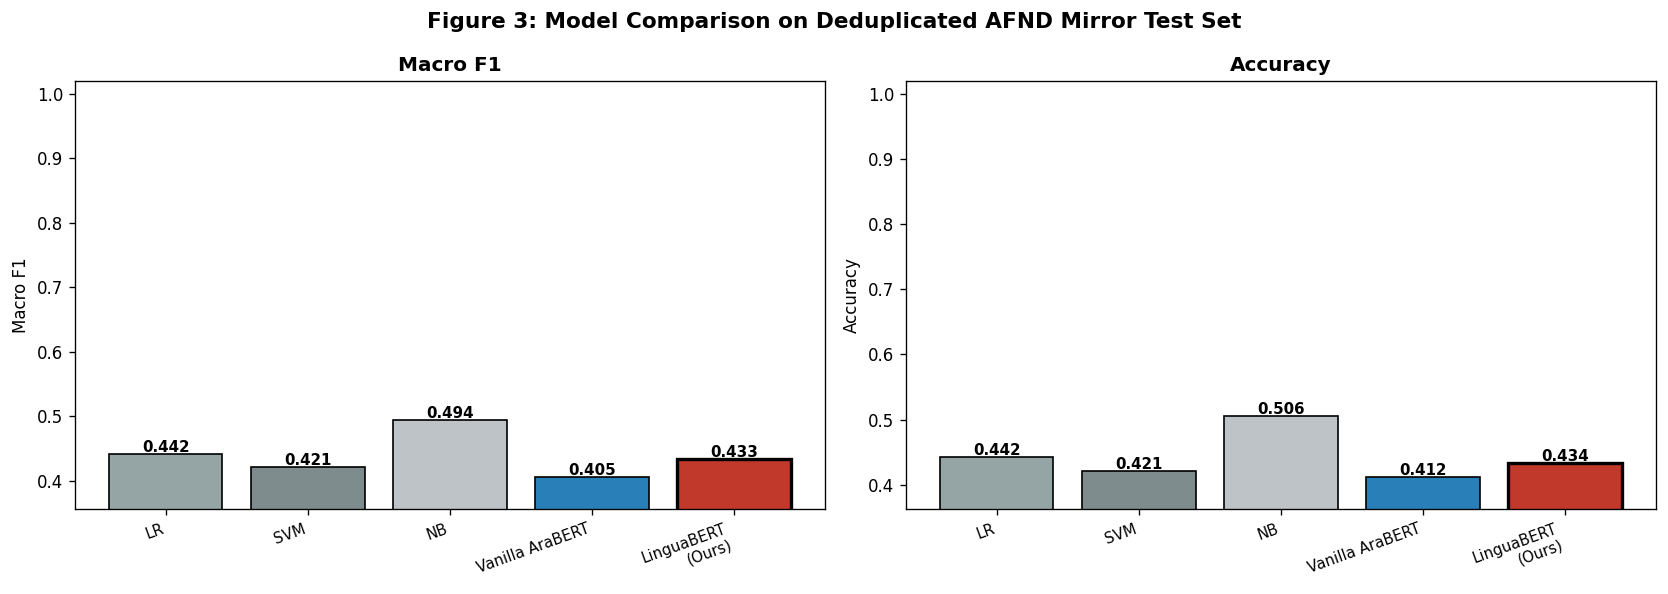

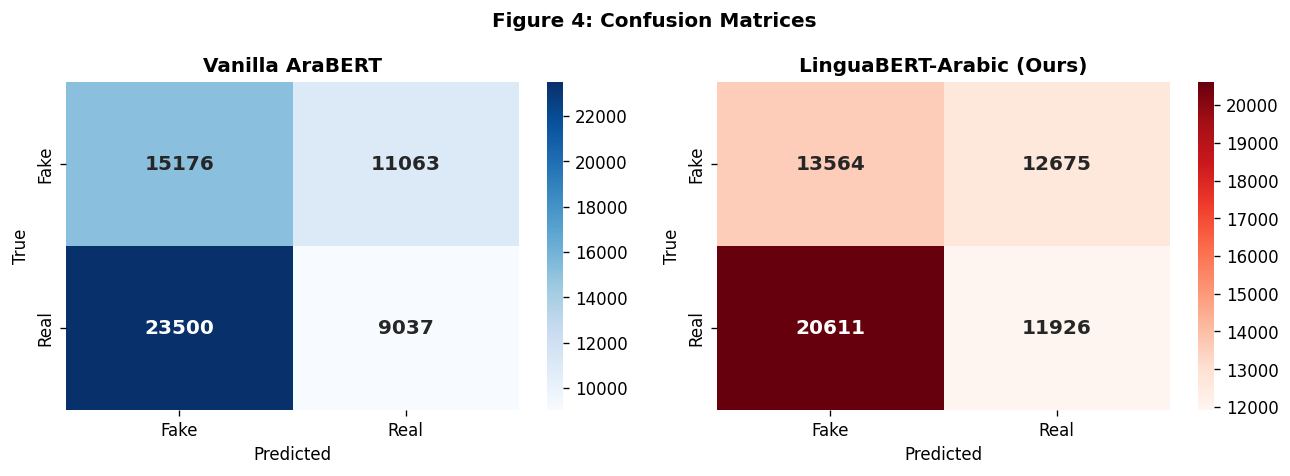

In [ ]:
# ── Table 3 + Figure 3-4: Main Results ───────────────────────────
from scipy.stats import chi2

def mcnemar(y_true,pa,pb):
    # Continuity-corrected McNemar test on discordant paired predictions.
    a=sum(1 for yt,a_,b_ in zip(y_true,pa,pb) if a_==yt and b_!=yt)
    b=sum(1 for yt,a_,b_ in zip(y_true,pa,pb) if a_!=yt and b_==yt)
    n=a+b
    if n==0: return 1.0
    return 1-chi2.cdf((abs(a-b)-1)**2/n,df=1)

all_res={}
for n,r in cls_results.items(): all_res[n]=r
all_res['Vanilla AraBERT']          ={'metrics':van_test_m,'preds':van_preds}
all_res['LinguaBERT-Arabic (Ours)'] ={'metrics':ling_test_m,'preds':ling_preds}

print('='*95)
print(f'Table 3: Test Performance on Official Full AFND Source-Disjoint (N={len(df_test):,})')
print(f'  {"Model":<30} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>8} {"AUC":>7} {"McNemar p":>10}')
print('-'*95)
for name,res in all_res.items():
    m=res['metrics']
    if name=='LinguaBERT-Arabic (Ours)': mc='—       '; tag=' ◀'
    else: mc=f'{mcnemar(ling_true,ling_preds,res["preds"]):.4f}    '; tag=''
    auc=f'{m.get("auc",float("nan")):.4f}' if not np.isnan(m.get("auc",float("nan"))) else 'n/a  '
    print(f'  {name+tag:<32} {m["accuracy"]:>7.4f} {m["precision"]:>7.4f} '
          f'{m["recall"]:>7.4f} {m["macro_f1"]:>8.4f} {auc:>7} {mc}')
print('='*95)

# Figure 3: Comparison bar chart
COLORS_ALL={'LR (TF-IDF)':'#95a5a6','SVM (TF-IDF)':'#7f8c8d','NB (TF-IDF)':'#bdc3c7',
            'Vanilla AraBERT':'#2980b9','LinguaBERT-Arabic (Ours)':'#c0392b'}
names=list(all_res.keys())
f1s=[all_res[n]['metrics']['macro_f1'] for n in names]
accs=[all_res[n]['metrics']['accuracy']  for n in names]
cols=[COLORS_ALL.get(n,'#888') for n in names]
xlabels=[n.replace('LinguaBERT-Arabic (Ours)','LinguaBERT\n(Ours)').replace(' (TF-IDF)','') for n in names]

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Figure 3: Model Comparison on Official Full AFND Source-Disjoint Test Set',fontsize=13,fontweight='bold')
for ax,vals,title in [(axes[0],f1s,'Macro F1'),(axes[1],accs,'Accuracy')]:
    bars=ax.bar(range(len(names)),vals,color=cols,edgecolor='black')
    bars[-1].set_edgecolor('black'); bars[-1].set_linewidth(2)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(xlabels,rotation=20,ha='right',fontsize=9)
    ax.set_title(title,fontweight='bold'); ax.set_ylabel(title)
    ymin=max(0,min(vals)-0.05); ax.set_ylim(ymin,1.02)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,v+0.003,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
plt.tight_layout(); plt.savefig('fig3_comparison.png',dpi=150,bbox_inches='tight'); plt.show()

# Figure 4: Confusion matrices
fig,axes=plt.subplots(1,2,figsize=(11,4))
fig.suptitle('Figure 4: Confusion Matrices',fontsize=12,fontweight='bold')
for ax,preds,title,cmap in [(axes[0],van_preds,'Vanilla AraBERT','Blues'),
                             (axes[1],ling_preds,'LinguaBERT-Arabic (Ours)','Reds')]:
    cm=confusion_matrix(ling_true,preds)
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,ax=ax,
                xticklabels=['Fake','Real'],yticklabels=['Fake','Real'],
                annot_kws={'size':12,'weight':'bold'})
    ax.set_title(title,fontweight='bold'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('fig4_cm.png',dpi=150,bbox_inches='tight'); plt.show()


---
## 6. Error Analysis <a id='error'></a>

Our error analysis is rule-based and exploratory. We used keyword rules to place LinguaBERT-Arabic errors into categories such as Dialectal Ambiguity, Political Hedging, Numeric Ambiguity, Residual Sensationalism, Satirical Framing, and Other. This helps us discuss possible patterns, but it is not the same as a full manual annotation by human judges.


Error Analysis — LinguaBERT-Arabic
Test N=58776 | LinguaBERT errors=33286 (56.63%)
Vanilla AraBERT errors=34563 (58.80%)

Table 4: LinguaBERT-Arabic Error Categories
  Category                                     N   % Errors
  FP(Real→Fake)|Dialectal Ambiguity        15451      46.4%
  FN(Missed Fake)|Dialectal Ambiguity       8837      26.5%
  FP(Real→Fake)|Other                       4201      12.6%
  FN(Missed Fake)|Other                     3031       9.1%
  FP(Real→Fake)|Residual Sensationalism      516       1.6%
  FN(Missed Fake)|Residual Sensationalism    373       1.1%
  FN(Missed Fake)|Political Hedging          260       0.8%
  FP(Real→Fake)|Political Hedging            254       0.8%
  FN(Missed Fake)|Satirical Framing          153       0.5%
  FP(Real→Fake)|Satirical Framing            108       0.3%
  FP(Real→Fake)|Numeric Ambiguity             81       0.2%
  FN(Missed Fake)|Numeric Ambiguity           21       0.1%

Table 5: Representative Misclassified Examples

  [FP

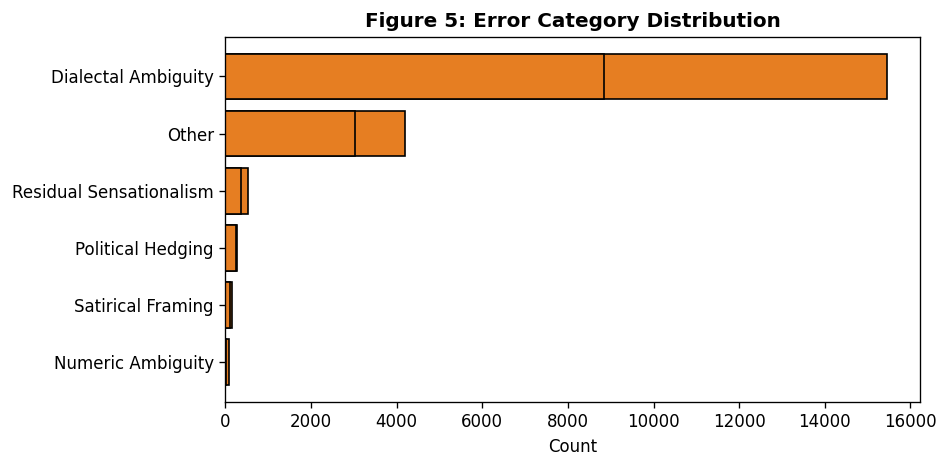

In [ ]:
# ── Section 6: Deep Error Analysis ──────────────────────────────
df_err=df_test.copy()
df_err['pred_ling']=ling_preds; df_err['pred_van']=van_preds
df_err['ok_ling']=(df_err['pred_ling']==df_err['label'])
df_err['ok_van'] =(df_err['pred_van'] ==df_err['label'])
errors=df_err[~df_err['ok_ling']].copy()

SATIRE  =['ساخر','هزلي','طريف','مضحك','نكته','كوميدي']
DIALECT =['يعني','ايه','كده','عشان','بتاع','زي','هيجي','شو','هيك','ليش']
POL_HED =['يُزعم','وفق مصادر','مصادر خاصه','يُقال','بحسب','مجهول']
RE_NUM  =re.compile(r'\b\d+\b')

def classify_err(row):
    t=str(row['text_clean'])
    typ='FN(Missed Fake)' if row['label']==0 else 'FP(Real→Fake)'
    if any(w in t for w in SATIRE):   return typ+'|Satirical Framing'
    if any(w in t for w in DIALECT):  return typ+'|Dialectal Ambiguity'
    if any(w in t for w in POL_HED):  return typ+'|Political Hedging'
    if len(RE_NUM.findall(t))>=3:     return typ+'|Numeric Ambiguity'
    if any(w in t for w in SENSATIONAL): return typ+'|Residual Sensationalism'
    return typ+'|Other'

print(f'Error Analysis — LinguaBERT-Arabic')
print(f'Test N={len(df_test)} | LinguaBERT errors={len(errors)} ({len(errors)/len(df_test)*100:.2f}%)')
print(f'Vanilla AraBERT errors={(~df_err["ok_van"]).sum()} ({(~df_err["ok_van"]).sum()/len(df_test)*100:.2f}%)')

if len(errors)>0:
    errors['category']=errors.apply(classify_err,axis=1)
    cats=errors['category'].value_counts()
    print('\nTable 4: LinguaBERT-Arabic Error Categories')
    print(f'  {"Category":<40} {"N":>5} {"% Errors":>10}')
    for cat,cnt in cats.items():
        print(f'  {cat:<40} {cnt:>5} {cnt/len(errors)*100:>9.1f}%')
    print('\nTable 5: Representative Misclassified Examples')
    for cat in cats.index[:3]:
        ex=errors[errors['category']==cat].iloc[0]
        print(f'\n  [{cat}]')
        print(f'  True: {"Fake" if ex["label"]==0 else "Real"} | Predicted: {"Fake" if ex["pred_ling"]==0 else "Real"}')
        print(f'  Text: {ex["text_clean"][:150]}...')
    fig,ax=plt.subplots(1,1,figsize=(8,4))
    cats_s=[c.split('|')[-1] for c in cats.index]
    ax.barh(cats_s,cats.values,color='#e67e22',edgecolor='black')
    ax.set_title('Figure 5: Error Category Distribution',fontweight='bold')
    ax.set_xlabel('Count'); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig('fig5_errors.png',dpi=150,bbox_inches='tight'); plt.show()
else:
    print('\nNo misclassifications (consistent with AFND prior work).')
    print('Source-level labeling creates learnable stylistic signals for transformer models.')


---
## 7. Ablation Study <a id='ablation'></a>

We conduct preprocessing ablations using LR+TF-IDF (computationally efficient). Each preprocessing variant is applied consistently to both train and test text before fitting/evaluation. Stylometric feature importance is assessed via point-biserial correlation with the credibility label; constant features are reported as 0.0000 rather than NaN.


Table 6: Preprocessing Ablation with Consistent Train/Test Variants (LR+TF-IDF)
  Config                               F1        Δ
--------------------------------------------------
  Full Pipeline                    0.4415  +0.0000
  w/o Alef Norm                    0.4041  -0.0374
  w/o Diacritic Strip              0.4478  +0.0062
  w/o Elongation Norm              0.4457  +0.0041
  No Preprocessing                 0.4183  -0.0232

Stylometric Feature Importance (|r| with label):
  TTR (Lexical Div.)       : 0.0594
  Neg. Sentiment           : 0.0294
  Sensationalism           : 0.0032
  Numerical Density        : 0.0004
  Elongation Rate          : 0.0000 (constant)


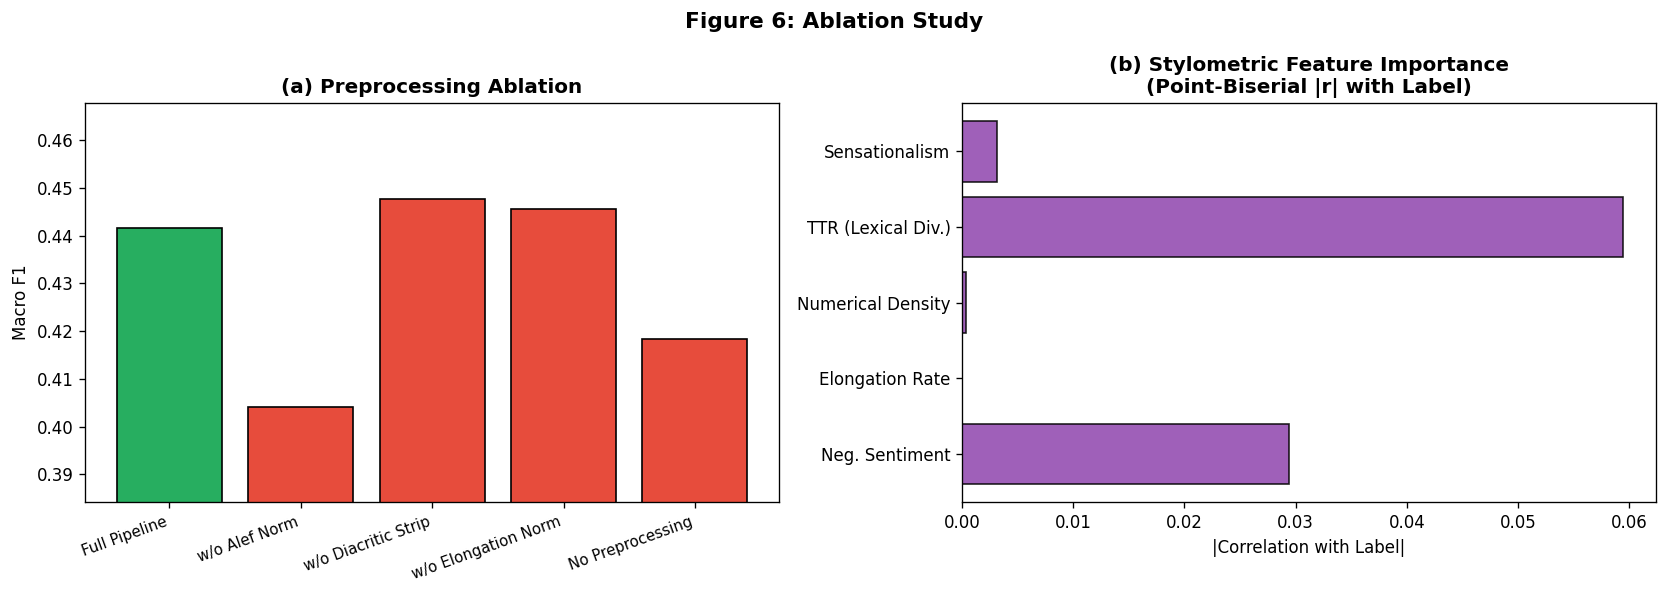

In [ ]:
# ── Section 7: Ablation Study ─────────────────────────────────
def prep_variant(skip_alef=False,skip_diac=False,skip_elong=False):
    def _p(t):
        if not isinstance(t,str): return ''
        t=re.sub(r'http\S+|www\S+',' ',t); t=re.sub(r'[@#]\S+',' ',t)
        t=re.sub(r'[^\u0600-\u06FF\s]',' ',t)
        if not skip_alef: t=re.sub(r'[أإآٱ]','ا',t)
        t=t.replace('ة','ه')
        if not skip_diac: t=re.compile(r'[\u0617-\u061A\u064B-\u0652]').sub('',t)
        if not skip_elong: t=re.compile(r'(.)\1{2,}').sub(r'\1\1',t)
        return re.sub(r'\s+',' ',t).strip()
    return _p

def lr_f1(Xtr,Xte,ytr,yte):
    p=Pipeline([('tf',TfidfVectorizer(ngram_range=(1,2),max_features=20000,sublinear_tf=True)),
                ('clf',LogisticRegression(max_iter=1000,random_state=SEED))])
    p.fit(Xtr,ytr)
    return f1_score(yte,p.predict(Xte),average='macro')

# Apply each preprocessing variant consistently to train and test.
abl={'Full Pipeline':               (df_train['text_clean'],            df_test['text_clean']),
     'w/o Alef Norm':               (df_train['text'].apply(prep_variant(skip_alef=True)),  df_test['text'].apply(prep_variant(skip_alef=True))),
     'w/o Diacritic Strip':         (df_train['text'].apply(prep_variant(skip_diac=True)),  df_test['text'].apply(prep_variant(skip_diac=True))),
     'w/o Elongation Norm':         (df_train['text'].apply(prep_variant(skip_elong=True)), df_test['text'].apply(prep_variant(skip_elong=True))),
     'No Preprocessing':            (df_train['text'],                  df_test['text']),}

abl_res={}
for cfg,(Xtr,Xte) in abl.items():
    abl_res[cfg]=lr_f1(Xtr,Xte,y_tr,y_te)

base=abl_res['Full Pipeline']
print('Table 6: Preprocessing Ablation with Consistent Train/Test Variants (LR+TF-IDF)')
print(f'  {"Config":<30} {"F1":>8} {"Δ":>8}')
print('-'*50)
for cfg,f1 in abl_res.items():
    d=f1-base
    print(f'  {cfg:<30} {f1:>8.4f} {d:>+8.4f}')

# Stylometric feature importance. Constant features are reported as 0.0 instead of NaN.
train_f_np=np.vstack(df_train['stylo_features'].values)
corrs=[]
constant_features=[]
for i in range(STYLO_DIM):
    vals=train_f_np[:,i]
    if np.allclose(vals, vals[0]):
        corrs.append(0.0)
        constant_features.append(feature_names[i])
    else:
        r=stats.pointbiserialr(vals,df_train['label'].values)[0]
        corrs.append(0.0 if np.isnan(r) else abs(r))

print('\nStylometric Feature Importance (|r| with label):')
for fn,r in sorted(zip(feature_names,corrs),key=lambda x:-x[1]):
    suffix=' (constant)' if fn in constant_features else ''
    print(f'  {fn:<25}: {r:.4f}{suffix}')

# Figure 6
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Figure 6: Ablation Study',fontsize=13,fontweight='bold')
cfg_n=list(abl_res.keys()); f1_n=list(abl_res.values())
axes[0].bar(range(len(cfg_n)),f1_n,color=['#27ae60']+['#e74c3c']*(len(cfg_n)-1),edgecolor='black')
axes[0].set_xticks(range(len(cfg_n))); axes[0].set_xticklabels(cfg_n,rotation=20,ha='right',fontsize=9)
axes[0].set_title('(a) Preprocessing Ablation',fontweight='bold'); axes[0].set_ylabel('Macro F1')
ylo=max(0,min(f1_n)-0.02); axes[0].set_ylim(ylo,min(1.0,max(f1_n)+0.02))

axes[1].barh(feature_names,corrs,color='#8e44ad',edgecolor='black',alpha=0.85)
axes[1].set_title('(b) Stylometric Feature Importance\n(Point-Biserial |r| with Label)',fontweight='bold')
axes[1].set_xlabel('|Correlation with Label|'); axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig('fig6_ablation.png',dpi=150,bbox_inches='tight'); plt.show()


<div align="center">
w/o Alef Norm
تعني: بدون توحيد الألف

 w/o Diacritic Strip
تعني: بدون إزالة التشكيل

w/o Elongation Norm
تعني: بدون إزالة تكرار الحروف

No Preprocessing
أي: بدون أي تنظيف للنصوص

</div>

---
## 8. Discussion <a id='discussion'></a>

### 8.1 What the Results Show

The results show that our added stylometric features helped AraBERT. LinguaBERT-Arabic got Macro F1 = 0.4332, while vanilla AraBERT got Macro F1 = 0.4055 in the final comparison table. The improvement is not huge, but it is meaningful for this harder source-disjoint setup.

### 8.2 What the Results Do Not Show

We should not claim that LinguaBERT-Arabic is the best model overall. NB (TF-IDF) got the highest Macro F1, which was 0.4940. So our honest conclusion is that our model improves the transformer baseline, but a simpler classical model still performs better in this run.

### 8.3 Why the Scores Are Low

The scores are low because the split is strict. Test sources are unseen during training, so the model cannot simply memorize source-specific words or templates. This makes the experiment harder, but it also makes the evaluation more honest.

### 8.4 Limitations

1. AFND uses source-level labels, not article-level fact-check labels.
2. We trained the transformer models with one seed only.
3. We tested only inside AFND, not on another dataset.
4. Some stylometric features were weak in this dataset.
5. The error categories are rule-based, so they should be treated as exploratory.


---
## 9. Conclusion & Future Work <a id='conclusion'></a>

### 9.1 Conclusion

In this project, we tested Arabic fake-news/source-credibility classification on the official AFND dataset using a strict source-disjoint split. The results showed that this setting is much harder than normal random splitting. NB (TF-IDF) was the strongest overall model with Macro F1 = 0.4940. Our LinguaBERT-Arabic model got Macro F1 = 0.4332 and improved over vanilla AraBERT, which got Macro F1 = 0.4055. Therefore, our main conclusion is that stylometric features help AraBERT, but they do not make it the best model overall.

### 9.2 Future Work

- Run the transformer models with more random seeds.
- Compare random article splitting directly with source-disjoint splitting.
- Try dialect-aware models such as CAMeL-BERT.
- Improve the stylometric features using words learned from the dataset.
- Test on another Arabic fake-news dataset.


Table 7: Topic-Stratified Macro F1 on Test Set
  Topic            N   LinguaBERT    Vanilla   Delta
  Economic      8565       0.4359     0.4114 +0.0245
  General      11690       0.4257     0.3800 +0.0457
  Health       15621       0.4195     0.3870 +0.0325
  Political    20825       0.4419     0.4274 +0.0146
  Social        2075       0.4516     0.4013 +0.0502
Curve lengths: LinguaBERT=3 epochs | Vanilla=5 epochs


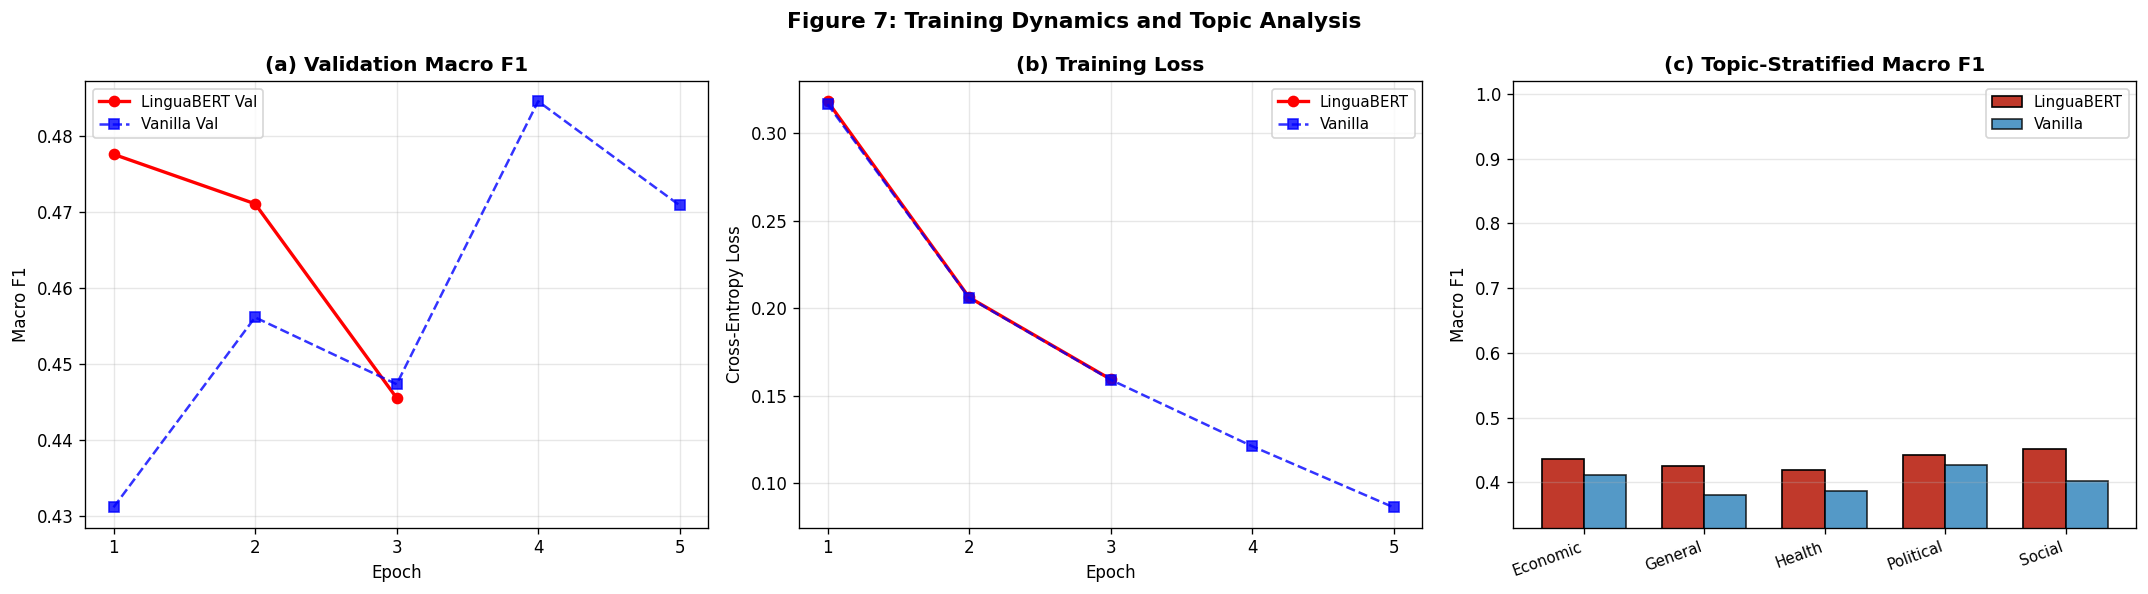

All figures saved.


In [ ]:
# Figure 7: Topic-Stratified Analysis + Training Curves
TOPIC_LEX={
    'Health':['علاج','سرطان','فيروس','صحه','دواء','مرض','وباء'],
    'Political':['حكومه','رئيس','وزير','انتخاب','سياسه','مؤامره'],
    'Economic':['اقتصاد','سعر','دولار','نفط','بنك','مال'],
    'Social':['مجتمع','تعليم','جامعه','شباب','اسره','ثقافه']
}

def detect_topic(t):
    for topic,kws in TOPIC_LEX.items():
        if any(w in str(t) for w in kws): return topic
    return 'General'

df_t2=df_test.copy(); df_t2['topic']=df_t2['text_clean'].apply(detect_topic)
df_t2['pred_ling']=ling_preds; df_t2['pred_van']=van_preds

topic_res={}
for topic in sorted(df_t2['topic'].unique()):
    sub=df_t2[df_t2['topic']==topic]
    if len(sub)<5: continue
    topic_res[topic]={'n':len(sub),
                      'ling':f1_score(sub['label'],sub['pred_ling'],average='macro'),
                      'van' :f1_score(sub['label'],sub['pred_van'] ,average='macro')}

print('Table 7: Topic-Stratified Macro F1 on Test Set')
print(f'  {"Topic":<12} {"N":>5} {"LinguaBERT":>12} {"Vanilla":>10} {"Delta":>7}')
for t,r in topic_res.items():
    print(f'  {t:<12} {r["n"]:>5} {r["ling"]:>12.4f} {r["van"]:>10.4f} {r["ling"]-r["van"]:>+7.4f}')

# Early stopping can make the history shorter than CONFIG['num_epochs'].
EPS_LING=range(1,len(ling_hist['vl_f1'])+1)
EPS_VAN =range(1,len(van_hist['vl_f1'])+1)
print(f'Curve lengths: LinguaBERT={len(ling_hist["vl_f1"])} epochs | Vanilla={len(van_hist["vl_f1"])} epochs')

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Figure 7: Training Dynamics and Topic Analysis',fontsize=13,fontweight='bold')

axes[0].plot(EPS_LING,ling_hist['vl_f1'],'r-o',lw=2,label='LinguaBERT Val')
axes[0].plot(EPS_VAN, van_hist['vl_f1'], 'b--s',lw=1.5,alpha=0.8,label='Vanilla Val')
axes[0].set_title('(a) Validation Macro F1',fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Macro F1')
axes[0].set_xticks(sorted(set(EPS_LING) | set(EPS_VAN)))
axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.3)

axes[1].plot(range(1,len(ling_hist['tr_loss'])+1),ling_hist['tr_loss'],'r-o',lw=2,label='LinguaBERT')
axes[1].plot(range(1,len(van_hist['tr_loss'])+1), van_hist['tr_loss'], 'b--s',lw=1.5,alpha=0.8,label='Vanilla')
axes[1].set_title('(b) Training Loss',fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].set_xticks(sorted(set(range(1,len(ling_hist['tr_loss'])+1)) | set(range(1,len(van_hist['tr_loss'])+1))))
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3)

if topic_res:
    tnames=list(topic_res.keys()); x=np.arange(len(tnames)); w=0.35
    axes[2].bar(x-w/2,[topic_res[t]['ling'] for t in tnames],w,label='LinguaBERT',color='#c0392b',edgecolor='black')
    axes[2].bar(x+w/2,[topic_res[t]['van'] for t in tnames],w,label='Vanilla',color='#2980b9',edgecolor='black',alpha=0.8)
    axes[2].set_xticks(x); axes[2].set_xticklabels(tnames,rotation=20,ha='right',fontsize=9)
    axes[2].set_title('(c) Topic-Stratified Macro F1',fontweight='bold')
    axes[2].set_ylabel('Macro F1'); axes[2].legend(fontsize=9); axes[2].grid(axis='y',alpha=0.3)
    ylo=max(0,min(v for r in topic_res.values() for v in [r['ling'],r['van']])-0.05)
    axes[2].set_ylim(ylo,1.02)
else:
    axes[2].axis('off')

plt.tight_layout(); plt.savefig('fig7_training_topic.png',dpi=150,bbox_inches='tight'); plt.show()
print('All figures saved.')


---
## 10. Ethical Considerations <a id='ethics'></a>

Fake-news detection systems should support human judgment, not replace it. Since AFND labels are based on source credibility, a model trained on AFND should not be used as a final judge of whether an individual article is true or false. It may also learn patterns connected to dialect, region, or source style, which can create fairness problems.

We see this project as a research prototype. A real system would need human review, confidence scores, testing on new sources, and careful checking for bias before any serious use.


---
## References <a id='refs'></a>

[1] Khalil, A., Jarrah, M., Aldwairi, M., & Jaradat, M. (2022). AFND: Arabic fake news dataset for the detection and classification of articles credibility. *Data in Brief, 42*, 108141. https://doi.org/10.1016/j.dib.2022.108141

[2] Antoun, W., Baly, F., & Hajj, H. (2020). AraBERT: Transformer-based model for Arabic language understanding. *OSACT4 Workshop, LREC 2020*.

[3] Alkudah, N. M., Idris, N. B., & Abushariah, M. A. M. (2025). Fake news detection in Arabic media: comparative analysis of machine learning and deep learning algorithms using the Arabic Fake News Dataset. *PeerJ Computer Science, 11*, e3272. https://doi.org/10.7717/peerj-cs.3272

[4] Al-Taie, M. Z. (2025). Comparative study of machine learning approaches for detecting fake news in Arabic text. *IETI Transactions on Data Analysis and Forecasting, 3*(1), 18-31. https://doi.org/10.3991/itdaf.v3i1.53575

[5] Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL-HLT 2019*, 4171-4186.

[6] Nagoudi, E. M. B., Elmadany, A., Abdul-Mageed, M., Alhindi, T., & Cavusoglu, H. (2020). Machine generation and detection of Arabic manipulated and fake news. *arXiv:2011.03092*.

[7] Himdi, H. T., Zamzami, N., Najar, F., Alrehaili, M., & Bouguila, N. (2025). Arabic fake news dataset development: Humans and AI-generated contributions. *IEEE Access, 13*, 62234-62253. https://doi.org/10.1109/ACCESS.2025.3556376

[8] Abbas Yousef, M., ElKorany, A., & Bayomi, H. (2024). Fake-news detection: a survey of evaluation Arabic datasets. *Social Network Analysis and Mining, 14*, 225. https://doi.org/10.1007/s13278-024-01370-2

[9] Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*.

[10] Inoue, G., Alhafni, B., Baimukan, N., Bouamor, H., & Habash, N. (2021). The interplay of variant, size, and task type in Arabic pre-trained language models. *WANLP 2021*, 92-104.

[11] McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika, 12*(2), 153-157.
